In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("Spark_MLlib_AnswerKey") \
    .getOrCreate()

# Đường dẫn gốc trên HDFS (Thay đổi theo thực tế của hệ thống cài đặt)
HDFS_PATH = "hdfs://localhost:9000/user/data/SQLdata/"

In [2]:
df_iris = spark.read.csv(HDFS_PATH + "iris.csv", header=True, inferSchema=True)

In [3]:
features_only_iris = df_iris.drop("species")
pdf_iris = features_only_iris.toPandas()

In [4]:
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler as SklearnStandardScaler
scaler_sk = SklearnStandardScaler()
X_scaled_iris = scaler_sk.fit_transform(pdf_iris)


In [6]:
spectral = SpectralClustering(n_clusters=3, affinity= 'rbf', random_state=42)
cluster_labels_iris = spectral.fit_predict(X_scaled_iris)


In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
# Đánh giá mô hình gom cụm
sil_score_iris = silhouette_score(X_scaled_iris, cluster_labels_iris)
dbi_score_iris = davies_bouldin_score(X_scaled_iris, cluster_labels_iris)
print("--- ĐÁNH GIÁ MÔ HÌNH SPECTRAL CLUSTERING (IRIS) ---")
print(f"Silhouette Score : {sil_score_iris:.4f} (Càng gần 1 càng tốt)")
print(f"Davies-Bouldin : {dbi_score_iris:.4f} (Càng nhỏ càng tốt)")
print("---------------------------------------------------")


--- ĐÁNH GIÁ MÔ HÌNH SPECTRAL CLUSTERING (IRIS) ---
Silhouette Score : 0.4630 (Càng gần 1 càng tốt)
Davies-Bouldin : 0.8257 (Càng nhỏ càng tốt)
---------------------------------------------------


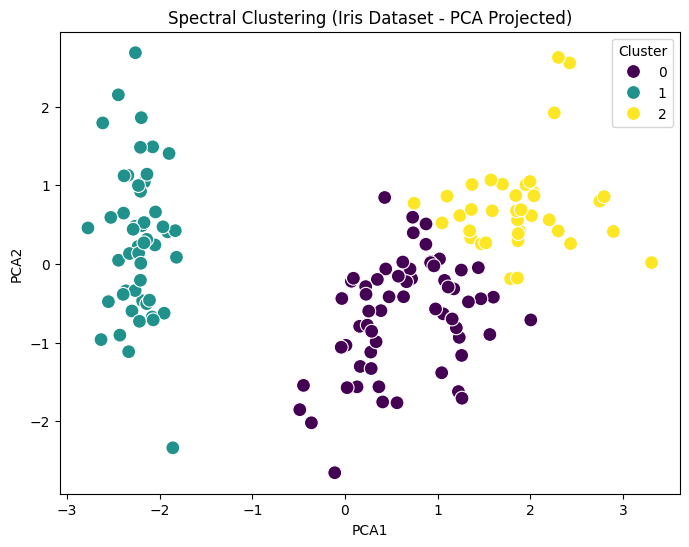

In [8]:
from sklearn.decomposition import PCA
pca_iris = PCA(n_components=2)
X_pca_iris = pca_iris.fit_transform(X_scaled_iris)
pdf_pca_iris = pd.DataFrame(X_pca_iris, columns=['PCA1', 'PCA2'])
pdf_pca_iris['Cluster'] = cluster_labels_iris
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pdf_pca_iris, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=100)
plt.title("Spectral Clustering (Iris Dataset - PCA Projected)")
plt.show()